In [15]:

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
# stylesheet
plt.style.use('Hannes_TUD.mplstyle')

Bad value in file 'Hannes_TUD.mplstyle', line 17 ("axes.prop_cycle: cycler(color=['D20F41','7569BE', 'BC1589', 'D20F41', '#C85000', '7FC6FF', 'C8C8FF', 'FFBFFF', 'FBEB78', 'FFC700', '7C7A23', '007D4B', '0A777F', 'FFE4B3', 'D2DC46', '8CE6AB', '8CE6D7', '000000', 'FFFFFF', '323F48', '566371', '7D8894', 'A5AEB8', 'D0D5DC', 'E7E9ED'])"): Key axes.prop_cycle: "cycler(color=['D20F41','7569BE', 'BC1589', 'D20F41', '" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


16
0.10190909090909092 1.0112783545585955 0.9979019438912907 1.0023607513003427


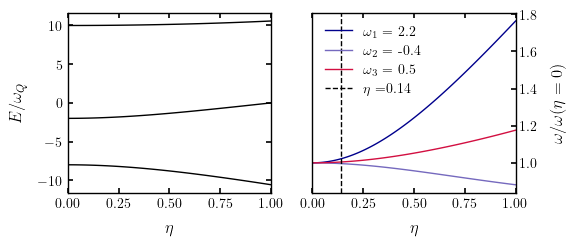

In [29]:
# create a 3 x 3 matrix with 0 
def diagw(w0, spin, m):
    return w0/6*(3*m**2-(spin*(spin+1)))
def diagA(w0, spin, m, eta):
    return w0/12 * eta * np.sqrt((spin-m-1)*(spin-m)*(spin+m+1)*(spin+m+2))
def diagB(w0, spin, m, eta):
    return w0/12 * eta * np.sqrt((spin+m-1)*(spin+m)*(spin-m+1)*(spin-m+2))
list_1 = [
    "#00008C",  # Brillantblau
    "#7569BE",  # Violett 1
    "#D20F41"   # Magenta 1
] 


h = 1
wq = 9
w0 = 6



def matrix(eta):
    A = np.zeros((6,6))
    spin = 5/2
    m = [-5/2, -3/2, -1/2, 1/2, 3/2 ,5/2]
    for i in range(6):
        A[i,i] = diagw(w0, spin, m[i])
    for i in range(4):
        A[i,i+2] = diagA(w0, spin, m[i], eta)
        A[i+2,i] = diagB(w0, spin, m[i+2], eta)
    ew = np.linalg.eig(A)[0]
    return ew, A
eta = np.linspace(0.001, 1, 100)
ew = np.zeros((100,6))

for i in range(100):
    ew[i], A = matrix(eta[i])

ew0, A = matrix(0.001)

# create a figure environment for two figures
fig, ax = plt.subplots(1,2, figsize=(5.78,2.34))
# use latex to add labels y axis eQV_(zz)/(4I(2I-1))
ax[0].set_ylabel(r'$E / \omega_Q$', fontsize=12)
ax[0].set_xlabel(r'$\eta$', fontsize=12)
ax[0].set_xlim(0,1)

# plot the eigenvalues
ax[0].plot(eta, ew[:,:3], color = 'black')
ratio = 186.7/360.6
# get me the position of the closest value to ratio in ratioa
print(np.abs(ratioa-ratio).argmin())
k1 = (ew[:,2]-ew[:,1])/(ew[0,2]-ew[0,1])
k2 = (ew[:,0]-ew[:,2])/(ew[0,0]-ew[0,2])
k3 = (ew[:,1]-ew[:,0])/(ew[0,1]-ew[0,0])
t = 14
ax[1].plot(eta, k1, color = list_1[0], label = r'$\omega_1$ = ' + str(round(round(k1[t]-1,3)*100,3))+ '%')
ax[1].plot(eta, k2, color = list_1[1], label = r'$\omega_2$ = ' + str(round(k2[t]-1,3)*100)+ '%')
ax[1].plot(eta, k3, color = list_1[2], label = r'$\omega_3$ = ' + str(round(k3[t]-1,3)*100)+ '%')
# add vertical line at eta[t]
ax[1].axvline(eta[t], color='black', linestyle='--', label = r'$\eta$ =' + str(round(eta[t],2)), ymax=1.2)
# labels 
ax[1].set_ylabel(r'$\omega/\omega(\eta = 0)$', fontsize=12)
ax[1].set_xlabel(r'$\eta$', fontsize=12)
# change side of y label to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_xlim(0,1)

ax[1].legend()
print(eta[10], k1[10], k2[10], k3[10])
plt.legend()
# save figure
plt.savefig('asymetry_energy_levels.pdf', bbox_inches='tight', dpi=300)
plt.show()



16
0.10190909090909092 1.0112783545585955 0.9979019438912907 1.0023607513003427


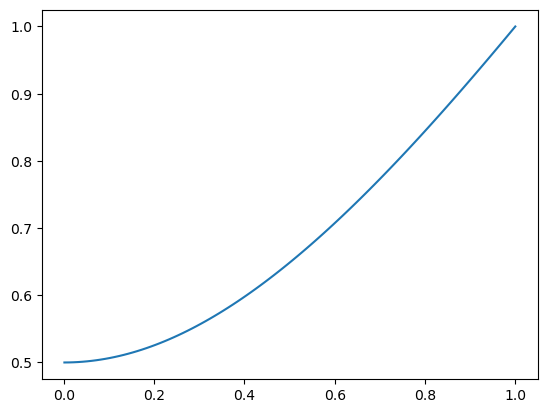

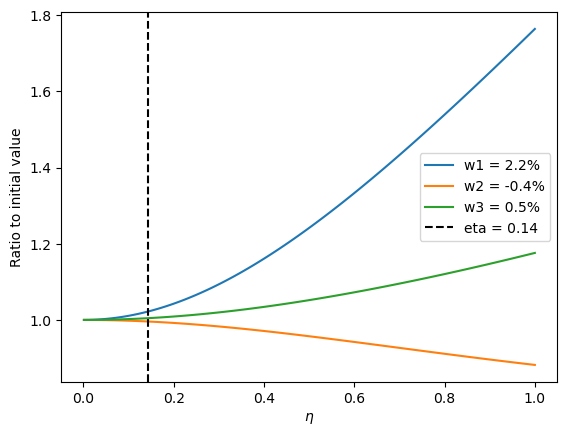

In [ ]:
fig, ax2 = plt.subplots(1,1)
ratioa = (ew[:,2]-ew[:,1])/(ew[:,0]-ew[:,2])
ax2.plot(eta, ratioa)


ratio = 186.7/360.6
# get me the position of the closest value to ratio in ratioa
print(np.abs(ratioa-ratio).argmin())
fig, ax3 = plt.subplots(1,1)
k1 = (ew[:,2]-ew[:,1])/(ew[0,2]-ew[0,1])
k2 = (ew[:,0]-ew[:,2])/(ew[0,0]-ew[0,2])
k3 = (ew[:,1]-ew[:,0])/(ew[0,1]-ew[0,0])
t = 14
ax3.plot(eta, k1, label = 'w1 = ' + str(round(round(k1[t]-1,3)*100,3))+ '%')
ax3.plot(eta, k2, label = 'w2 = ' + str(round(k2[t]-1,3)*100)+ '%')
ax3.plot(eta, k3, label = 'w3 = ' + str(round(k3[t]-1,3)*100)+ '%')
# add horizontal line at eta[t]
ax3.axvline(eta[t], color='black', linestyle='--', label = 'eta = ' + str(round(eta[t],2)))
# labels 
ax3.set_ylabel('Ratio to initial value')
ax3.set_xlabel(r'$\eta$')

plt.legend()
print(eta[10], k1[10], k2[10], k3[10])



In [4]:
import numpy as n
from sympy.physics.wigner import wigner_3j

I = 5/2 
k1 = 4
k2 = 4
ma = [-5/2, -3/2, -1/2, 1/2, 3/2, 5/2]
SKKN22 = 0
for mb in ma:
    for m in ma:
        SKKN = wigner_3j(I, I, k2, mb, -m, -mb+m) 
        SKKN22 += SKKN**2

print(SKKN22)

1


In [5]:
# Winkel Wigner ROtation
import numpy as np
import scipy.special as sp

def wigner_d(j, m, mb, alpha, beta, gamma):
    """Compute a single element of the Wigner D-matrix."""
    k_max = int(min(j + m, j - mb, mb - m))
    D = 0
    
    for k in range(k_max + 1):
        # Avoid invalid factorial arguments
        if j + m - k < 0 or j - mb - k < 0 or k - m + mb < 0:
            continue
        
        numerator = (sp.factorial(j + m) *
                     sp.factorial(j - m) *
                     sp.factorial(j + mb) *
                     sp.factorial(j - mb))

        denominator = (sp.factorial(j + m - k) *
                       sp.factorial(j - mb - k) *
                       sp.factorial(k - m + mb))
        
        if denominator == 0:
            continue  # Skip this term if the denominator is zero
        
        term = ((-1)**(k - m + mb) *
                 (numerator**0.5 / denominator) *
                 np.cos(beta / 2)**(2 * j + m - mb - 2 * k) *
                 np.sin(beta / 2)**(-m + mb + 2 * k))

        D += term

    D *= np.exp(-1j * (m * alpha + mb * gamma))
    return D

def wigner_d_matrix(j, alpha, beta, gamma):
    """Compute the full Wigner D-matrix."""
    m_values = np.arange(-j, j + 1, 1)  # Range of m values
    D_matrix = np.zeros((len(m_values), len(m_values)), dtype=complex)
    
    for i, m in enumerate(m_values):
        for j_idx, mb in enumerate(m_values):
            D_matrix[i, j_idx] = wigner_d(j, m, mb, alpha, beta, gamma)
    
    return D_matrix

# Example parameters for I = 5/2
j = 5 / 2
alpha = np.pi / 2
beta = np.pi / 2
gamma = 0

# Calculate the Wigner D-matrix
D_matrix = wigner_d_matrix(j, alpha, beta, gamma)

# Check if the matrix is unitary
D_dagger = np.conjugate(D_matrix.T)
unitary_check = np.dot(D_matrix, D_dagger)

# Print results

print("\nProduct D_matrix * D_dagger:")
print(unitary_check)

# Check if the result is close to the identity matrix
identity_matrix = np.eye(D_matrix.shape[0])
is_unitary = np.allclose(unitary_check, identity_matrix, atol=1e-10)

print("Is the D_matrix unitary?", is_unitary)
# calculate D^dagger A D
A = A
D_dagger = np.conjugate(D_matrix.T)
D = D_matrix
A_prime = np.dot(D_dagger, np.dot(A, D))
print(A_prime)
# print the eigenvalues of A_prime
print(np.linalg.eig(A_prime)[0])



Product D_matrix * D_dagger:
[[ 1.00000000e+00-1.04083409e-17j -4.32714141e-17-3.49385621e-01j
   5.66371787e-17+1.12602747e-18j  2.19427092e-17+9.88211769e-02j
   1.39754249e-01-4.16333634e-17j -1.04083409e-17-3.12500000e-02j]
 [-4.32714141e-17+3.49385621e-01j  5.93750000e-01+1.12003280e-17j
  -1.21256343e-17-1.76776695e-01j -1.32582521e-01+2.76414728e-17j
   4.16333634e-17+2.50000000e-01j  6.98771243e-02-2.08166817e-17j]
 [ 5.66371787e-17+4.03246069e-18j -1.21256343e-17+1.76776695e-01j
   6.87500000e-01-3.08879771e-18j -2.50315069e-17-1.56250000e-01j
  -2.65165043e-01+5.55111512e-17j  2.77555756e-17+9.88211769e-02j]
 [ 2.19427092e-17-9.88211769e-02j -1.32582521e-01-2.36948627e-17j
  -2.50315069e-17+1.56250000e-01j  4.06250000e-01+3.08879771e-18j
   0.00000000e+00-1.76776695e-01j -9.88211769e-02+1.38777878e-17j]
 [ 1.39754249e-01+3.38754442e-17j  4.92249752e-17-2.50000000e-01j
  -2.65165043e-01-4.37713155e-17j -4.99901462e-19+1.76776695e-01j
   1.87500000e-01+0.00000000e+00j -6.93889